In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.optimizers import Adam

import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [2]:
df=pd.read_csv("C:/Users/Dhruv/Onedrive/Desktop/samsung/aqi/delhi_ncr_aqi_dataset.csv")
df

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
201660,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
201661,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe
201662,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Ghaziabad,...,170.7,20.9,6.98,22.9,15.4,51,6.8,1.2,500,Severe


In [3]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Jahangirpuri, Delhi', 'Wazirpur, Delhi',
       'Bawana, Delhi', 'ITO, Delhi', 'Punjabi Bagh, Delhi',
       'Okhla Phase 2, Delhi', 'Shadipur, Delhi', 'Rohini, Delhi',
       'RK Puram, Delhi', 'Siri Fort, Delhi', 'Dwarka Sec 8, Delhi',
       'NSIT Dwarka, Delhi', 'Mandir Marg, Delhi', 'Noida Sec 62',
       'Noida Sec 125', 'Greater Noida', 'Gurugram Vikas Sadan',
       'Gurugram Sec 51', 'Faridabad Sec 16A', 'Faridabad New Town',
       'Ghaziabad Vasundhara', 'Ghaziabad Loni'], dtype=object)

In [4]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [5]:
df = df.sort_values('datetime').reset_index(drop=True)


In [6]:
df=df[['year', 'month', 'day', 'hour',
       'is_weekend','season', 'station','pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi']]

In [7]:
df

,year,month,day,hour,is_weekend,season,station,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
0,2020,1,1,6,0,winter,"Anand Vihar, Delhi",371.8,739.4,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500
1,2020,1,1,6,0,winter,"Mandir Marg, Delhi",248.2,424.5,94.7,16.4,4.38,24.5,8.3,100,3.6,1.7,399
2,2020,1,1,6,0,winter,"NSIT Dwarka, Delhi",327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,500
3,2020,1,1,6,0,winter,Noida Sec 125,266.3,572.8,86.0,18.6,3.26,20.9,9.4,100,3.5,2.9,500
4,2020,1,1,6,0,winter,"Dwarka Sec 8, Delhi",269.8,488.6,89.8,15.9,4.23,21.5,7.4,100,3.4,2.6,473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025,12,31,23,0,winter,Noida Sec 62,340.1,600.4,138.7,27.6,5.17,14.8,14.8,48,6.8,0.8,500
201660,2025,12,31,23,0,winter,Noida Sec 125,249.2,501.2,93.0,14.4,3.12,28.2,15.7,51,6.2,2.3,489
201661,2025,12,31,23,0,winter,Greater Noida,264.0,568.9,92.2,15.5,4.07,23.3,16.0,54,4.3,2.7,500
201662,2025,12,31,23,0,winter,"Wazirpur, Delhi",440.1,816.5,167.1,54.9,5.45,12.9,17.7,64,6.5,1.0,500


In [8]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Mandir Marg, Delhi', 'NSIT Dwarka, Delhi',
       'Noida Sec 125', 'Dwarka Sec 8, Delhi', 'Greater Noida',
       'Siri Fort, Delhi', 'RK Puram, Delhi', 'Gurugram Vikas Sadan',
       'Rohini, Delhi', 'Gurugram Sec 51', 'Shadipur, Delhi',
       'Okhla Phase 2, Delhi', 'Faridabad Sec 16A', 'Punjabi Bagh, Delhi',
       'Faridabad New Town', 'Noida Sec 62', 'Wazirpur, Delhi',
       'Ghaziabad Loni', 'Ghaziabad Vasundhara', 'ITO, Delhi',
       'Bawana, Delhi', 'Jahangirpuri, Delhi'], dtype=object)

In [9]:
df1=df[df['station'] == 'NSIT Dwarka, Delhi']
df1=df1.drop(columns=['station'])
df1

,year,month,day,hour,is_weekend,season,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
2,2020,1,1,6,0,winter,327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,500
25,2020,1,1,12,0,winter,231.1,436.6,95.0,18.3,3.92,25.1,17.2,46,9.9,2.6,408
67,2020,1,1,18,0,winter,271.6,483.2,128.4,25.2,5.75,25.6,14.1,64,6.6,2.5,466
70,2020,1,1,23,0,winter,324.8,655.0,104.1,27.3,4.49,17.5,12.5,45,4.4,0.7,500
98,2020,1,2,6,0,winter,350.2,636.3,125.5,20.4,4.44,15.3,6.3,100,2.4,0.8,500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,winter,272.5,574.7,107.4,25.9,4.77,22.4,14.3,49,6.8,2.9,500
201578,2025,12,31,6,0,winter,308.5,666.1,88.9,29.1,5.50,16.8,8.2,100,2.5,0.8,500
201597,2025,12,31,12,0,winter,183.5,369.0,59.3,18.2,2.99,28.5,21.3,63,8.8,3.1,349
201627,2025,12,31,18,0,winter,260.0,450.7,147.3,21.2,5.53,25.1,16.4,61,5.9,2.9,426


In [10]:
df1['season'].unique()

array(['winter', 'summer', 'monsoon', 'post_monsoon'], dtype=object)

In [11]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [12]:
df1

,year,month,day,hour,is_weekend,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,season_post_monsoon,season_summer,season_winter
2,2020,1,1,6,0,327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,500,False,False,True
25,2020,1,1,12,0,231.1,436.6,95.0,18.3,3.92,25.1,17.2,46,9.9,2.6,408,False,False,True
67,2020,1,1,18,0,271.6,483.2,128.4,25.2,5.75,25.6,14.1,64,6.6,2.5,466,False,False,True
70,2020,1,1,23,0,324.8,655.0,104.1,27.3,4.49,17.5,12.5,45,4.4,0.7,500,False,False,True
98,2020,1,2,6,0,350.2,636.3,125.5,20.4,4.44,15.3,6.3,100,2.4,0.8,500,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,272.5,574.7,107.4,25.9,4.77,22.4,14.3,49,6.8,2.9,500,False,False,True
201578,2025,12,31,6,0,308.5,666.1,88.9,29.1,5.50,16.8,8.2,100,2.5,0.8,500,False,False,True
201597,2025,12,31,12,0,183.5,369.0,59.3,18.2,2.99,28.5,21.3,63,8.8,3.1,349,False,False,True
201627,2025,12,31,18,0,260.0,450.7,147.3,21.2,5.53,25.1,16.4,61,5.9,2.9,426,False,False,True


In [13]:
df.isna().sum()

year           0
month          0
day            0
hour           0
is_weekend     0
season         0
station        0
pm25           0
pm10           0
no2            0
so2            0
co             0
o3             0
temperature    0
humidity       0
wind_speed     0
visibility     0
aqi            0
dtype: int64

In [14]:
df1=df1.apply(pd.to_numeric)
df1.dtypes

year                     int64
month                    int64
day                      int64
hour                     int64
is_weekend               int64
pm25                   float64
pm10                   float64
no2                    float64
so2                    float64
co                     float64
o3                     float64
temperature            float64
humidity                 int64
wind_speed             float64
visibility             float64
aqi                      int64
season_post_monsoon       bool
season_summer             bool
season_winter             bool
dtype: object

In [15]:
X=df1.drop(columns=["aqi"])
Y=df1["aqi"]
X

,year,month,day,hour,is_weekend,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,season_post_monsoon,season_summer,season_winter
2,2020,1,1,6,0,327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,False,False,True
25,2020,1,1,12,0,231.1,436.6,95.0,18.3,3.92,25.1,17.2,46,9.9,2.6,False,False,True
67,2020,1,1,18,0,271.6,483.2,128.4,25.2,5.75,25.6,14.1,64,6.6,2.5,False,False,True
70,2020,1,1,23,0,324.8,655.0,104.1,27.3,4.49,17.5,12.5,45,4.4,0.7,False,False,True
98,2020,1,2,6,0,350.2,636.3,125.5,20.4,4.44,15.3,6.3,100,2.4,0.8,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,272.5,574.7,107.4,25.9,4.77,22.4,14.3,49,6.8,2.9,False,False,True
201578,2025,12,31,6,0,308.5,666.1,88.9,29.1,5.50,16.8,8.2,100,2.5,0.8,False,False,True
201597,2025,12,31,12,0,183.5,369.0,59.3,18.2,2.99,28.5,21.3,63,8.8,3.1,False,False,True
201627,2025,12,31,18,0,260.0,450.7,147.3,21.2,5.53,25.1,16.4,61,5.9,2.9,False,False,True


In [16]:
df1['aqi_lag_1']  = df1['aqi'].shift(1)   # 6 hours ago
df1['aqi_lag_2']  = df1['aqi'].shift(2)   # 12 hours ago
df1['aqi_lag_4']  = df1['aqi'].shift(4)   # 24 hours ago (daily cycle)
df1['aqi_lag_8']  = df1['aqi'].shift(8)   # 48 hours ago
df1['aqi_lag_28'] = df1['aqi'].shift(28)  # ~7 days

In [17]:
df1 = df1.dropna().reset_index(drop=True)


In [18]:
bool_cols = df1.select_dtypes(include='bool').columns
df1[bool_cols] = df1[bool_cols].astype(int)
df1

,year,month,day,hour,is_weekend,pm25,pm10,no2,so2,co,...,visibility,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
0,2020,1,8,6,0,367.1,648.7,108.9,26.3,5.68,...,0.5,500,0,0,1,500.0,405.0,500.0,500.0,500.0
1,2020,1,8,12,0,221.7,428.5,76.4,13.4,3.29,...,2.5,398,0,0,1,500.0,500.0,351.0,460.0,408.0
2,2020,1,8,18,0,228.5,375.6,129.2,16.8,4.81,...,2.1,383,0,0,1,398.0,500.0,405.0,500.0,466.0
3,2020,1,8,23,0,292.3,637.7,94.5,26.8,4.07,...,2.2,500,0,0,1,383.0,398.0,500.0,490.0,500.0
4,2020,1,9,6,0,268.0,545.5,96.8,22.7,4.47,...,3.0,500,0,0,1,500.0,383.0,500.0,500.0,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,272.5,574.7,107.4,25.9,4.77,...,2.9,500,0,0,1,390.0,372.0,435.0,389.0,500.0
8736,2025,12,31,6,0,308.5,666.1,88.9,29.1,5.50,...,0.8,500,0,0,1,500.0,390.0,500.0,500.0,500.0
8737,2025,12,31,12,0,183.5,369.0,59.3,18.2,2.99,...,3.1,349,0,0,1,500.0,500.0,372.0,451.0,394.0
8738,2025,12,31,18,0,260.0,450.7,147.3,21.2,5.53,...,2.9,426,0,0,1,349.0,500.0,390.0,416.0,442.0


In [19]:
train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]


X_train = train_df.drop(columns=['aqi'])
Y_train = train_df['aqi']

X_test = test_df.drop(columns=['aqi'])
Y_test = test_df['aqi']


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [21]:
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(X_train_scaled, Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = mlr.predict(X_test_scaled)


In [28]:
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
r2= r2_score(Y_test, y_pred)


print("MLR MAE:", mae)
print("MLR RMSE:", rmse)
print("MLR R2:", r2)



MLR MAE: 23.04479214969895
MLR RMSE: 29.743138847308618
MLR R2: 0.9688927738365042


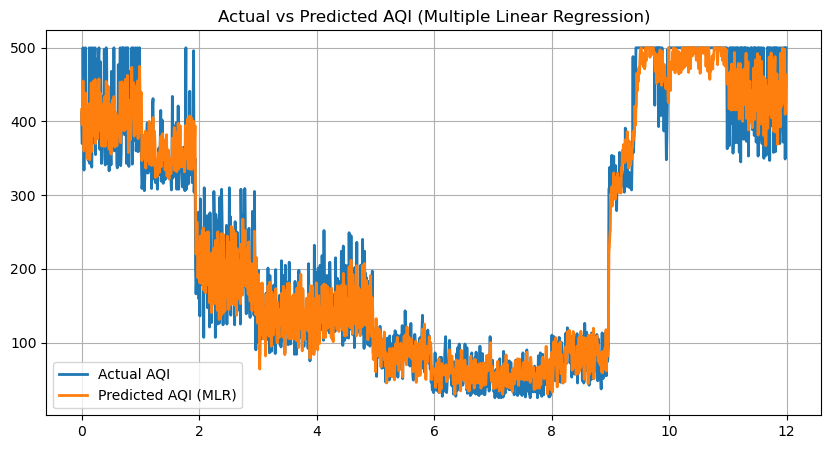

In [24]:
import matplotlib.pyplot as plt
y_pred = np.clip(y_pred, 0, 500)
plt.figure(figsize=(10, 5))
# Number of samples
n_samples = len(Y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,Y_test.values, label="Actual AQI", linewidth=2)
plt.plot(x_months,y_pred, label="Predicted AQI (MLR)", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("Actual vs Predicted AQI (Multiple Linear Regression)")
plt.show()
